# [Perfect] 칼로리 예측 - Keytel 공식 역공학

## 핵심 발견 요약
- 데이터가 **100% 결정론적** (같은 피처 → 항상 같은 칼로리)
- `Calories_Burned`가 모두 **정수** (1~300)
- Weight(lb) 값이 **2.2 lb 단위** = 원래 **정수 kg** 데이터
- **Keytel(2005) 공식**의 BPM/Age 계수가 정확히 일치
- Weight 계수만 그리드 서치로 최적화 → **Train RMSE = 0.0000 (100% 정확)**

## 최종 공식
```
W_kg_int = round(Weight(lb) / 2.20462)   # 정수 kg 복원

Male:   Cal = round((0.15079×BPM + 0.02160×W_kg_int + 0.04821×Age − 13.168) × Duration)
Female: Cal = round((0.10688×BPM − 0.01372×W_kg_int + 0.01769×Age − 4.876) × Duration)
```

## 0. 라이브러리 및 설정

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import koreanize_matplotlib

BASE = './'  # 데이터(train.csv, test.csv)를 이 노트북과 같은 폴더에 두세요
# BASE = '/content/drive/MyDrive/'  # Google Colab 사용 시 이 줄로 교체

# Keytel(2005) 공식 계수 (공개 논문)
# Male:   (-55.0969 + 0.6309×HR + 0.1988×W_kg + 0.2017×Age) / 4.184 × Duration
# Female: (-20.4022 + 0.4472×HR - 0.1263×W_kg + 0.0740×Age) / 4.184 × Duration
KEYTEL_M = {
    'bpm': 0.6309 / 4.184,   # = 0.15079
    'age': 0.2017 / 4.184,   # = 0.04821
    'ic' : -55.0969 / 4.184  # = -13.168
}
KEYTEL_F = {
    'bpm': 0.4472 / 4.184,   # = 0.10688
    'age': 0.0740 / 4.184,   # = 0.01769
    'ic' : -20.4022 / 4.184  # = -4.876
}

RANDOM_STATE = 42
print('설정 완료')

## 1. 데이터 로드

In [13]:
train = pd.read_csv(BASE + 'train.csv')
test  = pd.read_csv(BASE + 'test.csv')

print('Train shape:', train.shape)
print('Test  shape:', test.shape)
print()
print(train.head(3))

Train shape: (7500, 11)
Test  shape: (7500, 10)

           ID  Exercise_Duration  Body_Temperature(F)    BPM  Height(Feet)  \
0  TRAIN_0000               26.0                105.6  107.0           5.0   
1  TRAIN_0001                7.0                103.3   88.0           6.0   
2  TRAIN_0002                7.0                103.3   86.0           6.0   

   Height(Remainder_Inches)  Weight(lb)  Weight_Status Gender  Age  \
0                       9.0       154.3  Normal Weight      F   45   
1                       6.0       224.9     Overweight      M   50   
2                       3.0       218.3     Overweight      M   29   

   Calories_Burned  
0            166.0  
1             33.0  
2             23.0  


## 2. 핵심 발견 1: 데이터가 100% 결정론적

In [14]:
# 같은 피처 조합에서 다른 칼로리가 나오는지 확인
all_features = ['BPM', 'Body_Temperature(F)', 'Weight(lb)', 'Height(Feet)',
                'Height(Remainder_Inches)', 'Gender', 'Age', 'Exercise_Duration']

grouped = train.groupby(all_features)['Calories_Burned']
inconsistent = (grouped.std().fillna(0) > 0).sum()

print(f'고유 피처 조합: {grouped.ngroups}')
print(f'같은 피처 → 다른 칼로리: {inconsistent}개')
print(f'결론: {"결정론적 ✓" if inconsistent == 0 else "비결정론적 ✗"}')
print()

# 칼로리가 모두 정수인지 확인
non_integer = (train['Calories_Burned'] % 1 != 0).sum()
print(f'칼로리 정수 여부: 소수점 있는 값 {non_integer}개')
print(f'칼로리 범위: {train["Calories_Burned"].min():.0f} ~ {train["Calories_Burned"].max():.0f}')

고유 피처 조합: 7499
같은 피처 → 다른 칼로리: 0개
결론: 결정론적 ✓

칼로리 정수 여부: 소수점 있는 값 0개
칼로리 범위: 1 ~ 300


## 3. 핵심 발견 2: Weight(lb) = 정수 kg × 2.20462

In [15]:
# Weight(lb) 값들의 간격 확인
weight_unique = sorted(train['Weight(lb)'].unique())
gaps = [round(weight_unique[i+1] - weight_unique[i], 3) for i in range(len(weight_unique)-1)]

print('Weight(lb) 고유값 수:', len(weight_unique))
print('처음 10개:', weight_unique[:10])
print('간격 분포:', pd.Series(gaps).value_counts().head())
print()
print('1 kg = 2.20462 lb → 간격 2.2 lb = 1 kg 단위!')
print()

# 정수 kg 복원 검증
train['Weight_kg_int'] = (train['Weight(lb)'] / 2.20462).round()
print('정수 kg 복원 예시:')
print(train[['Weight(lb)', 'Weight_kg_int']].head(8))
print()
print('모두 정수인가?', (train['Weight_kg_int'] % 1 == 0).all())
print('정수 kg 범위:', int(train['Weight_kg_int'].min()), '~', int(train['Weight_kg_int'].max()), 'kg')

Weight(lb) 고유값 수: 88
처음 10개: [np.float64(79.4), np.float64(83.8), np.float64(86.0), np.float64(88.2), np.float64(90.4), np.float64(92.6), np.float64(94.8), np.float64(97.0), np.float64(99.2), np.float64(101.4)]
간격 분포: 2.2     81
2.3      3
4.4      1
4.5      1
17.6     1
Name: count, dtype: int64

1 kg = 2.20462 lb → 간격 2.2 lb = 1 kg 단위!

정수 kg 복원 예시:
   Weight(lb)  Weight_kg_int
0       154.3           70.0
1       224.9          102.0
2       218.3           99.0
3       147.7           67.0
4       169.8           77.0
5       191.8           87.0
6       196.2           89.0
7       130.1           59.0

모두 정수인가? True
정수 kg 범위: 36 ~ 132 kg


## 4. 핵심 발견 3: Keytel 공식과의 연관성 (LinearRegression)

In [16]:
from sklearn.linear_model import LinearRegression

# 선형 회귀로 계수 추정
train['Duration'] = train['Exercise_Duration']
train['is_M']     = (train['Gender'] == 'M').astype(int)
train['cal_per_dur'] = train['Calories_Burned'] / train['Duration']

print('=== 회귀 추정 계수 vs Keytel/4.184 ===\n')
for gender, kcoef, g_label in [(1, KEYTEL_M, 'Male'), (0, KEYTEL_F, 'Female')]:
    mask = train['is_M'] == gender
    X = train.loc[mask, ['BPM', 'Age']].values
    y = train.loc[mask, 'cal_per_dur'].values
    reg = LinearRegression().fit(X, y)
    print(f'[{g_label}]')
    print(f'  BPM  회귀={reg.coef_[0]:.7f}  Keytel={kcoef["bpm"]:.7f}  차이={abs(reg.coef_[0]-kcoef["bpm"]):.2e}')
    print(f'  Age  회귀={reg.coef_[1]:.7f}  Keytel={kcoef["age"]:.7f}  차이={abs(reg.coef_[1]-kcoef["age"]):.2e}')
    print(f'  ic   회귀={reg.intercept_:.6f}  Keytel={kcoef["ic"]:.6f}  차이={abs(reg.intercept_-kcoef["ic"]):.2e}')
    print()

=== 회귀 추정 계수 vs Keytel/4.184 ===

[Male]
  BPM  회귀=0.1505773  Keytel=0.1507887  차이=2.11e-04
  Age  회귀=0.0501138  Keytel=0.0482075  차이=1.91e-03
  ic   회귀=-11.353147  Keytel=-13.168475  차이=1.82e+00

[Female]
  BPM  회귀=0.1068395  Keytel=0.1068834  차이=4.38e-05
  Age  회귀=0.0167893  Keytel=0.0176864  차이=8.97e-04
  ic   회귀=-5.701396  Keytel=-4.876243  차이=8.25e-01



## 5. Weight 계수(k_W) 추정

In [17]:
# Keytel BPM/Age/ic 고정 → 잔여분 = k_W × W_kg_int
print('=== k_W 역추산 (중앙값) ===')
kW_estimates = {}
for gender, kcoef, g_label in [(1, KEYTEL_M, 'Male'), (0, KEYTEL_F, 'Female')]:
    mask = train['is_M'] == gender
    d = train[mask]
    partial   = kcoef['bpm']*d['BPM'] + kcoef['age']*d['Age'] + kcoef['ic']
    remaining = d['cal_per_dur'] - partial
    k_W_vals  = remaining / d['Weight_kg_int']
    kW_estimates[gender] = k_W_vals.median()
    print(f'{g_label}: 중앙값={k_W_vals.median():.9f}, std={k_W_vals.std():.8f}')

print()
print('초기 k_W 추정치 → 다음 셀에서 그리드 서치로 정밀화')

=== k_W 역추산 (중앙값) ===
Male: 중앙값=0.021591747, std=0.00064228
Female: 중앙값=-0.013707311, std=0.00090950

초기 k_W 추정치 → 다음 셀에서 그리드 서치로 정밀화


## 6. Greed Search: 최적 k_W 탐색

In [18]:
def predict_with_kW(kW_M, kW_F, df=train):
    """Keytel 공식 + 최적 Weight 계수로 예측"""
    preds = np.zeros(len(df))
    for gender, kcoef, kW in [(1, KEYTEL_M, kW_M), (0, KEYTEL_F, kW_F)]:
        mask = df['is_M'] == gender
        d    = df[mask]
        pred_per_min = (kcoef['bpm']*d['BPM'] +
                        kcoef['age']*d['Age']  +
                        kW  *d['Weight_kg_int'] +
                        kcoef['ic'])
        preds[mask] = pred_per_min * d['Duration']
    if 'Calories_Burned' in df.columns:
        actual  = df['Calories_Burned'].values
        exact   = (np.round(preds) == actual).mean()
        rmse_r  = np.sqrt(np.mean((actual - np.round(preds))**2))
        return exact, rmse_r, preds
    return None, None, preds

# 초기값
kW_M_init = kW_estimates[1]
kW_F_init = kW_estimates[0]

e0, rr0, _ = predict_with_kW(kW_M_init, kW_F_init)
print(f'초기값: Exact={e0:.5f}, R.RMSE={rr0:.5f}')

# 1차: 넓은 범위 서치 (0.00001 간격)
best_exact, best_rr = e0, rr0
best_kW_M, best_kW_F = kW_M_init, kW_F_init

for kW_M in np.arange(kW_M_init - 0.0005, kW_M_init + 0.0006, 0.00001):
    for kW_F in np.arange(kW_F_init - 0.0005, kW_F_init + 0.0006, 0.00001):
        e, rr, _ = predict_with_kW(kW_M, kW_F)
        if e > best_exact or (e == best_exact and rr < best_rr):
            best_exact, best_rr = e, rr
            best_kW_M, best_kW_F = kW_M, kW_F

print(f'1차 서치: M={best_kW_M:.8f}, F={best_kW_F:.8f}')
print(f'          Exact={best_exact:.5f}, R.RMSE={best_rr:.5f}')

# 2차: 세밀 서치 (0.0000005 간격)
prev_M, prev_F = best_kW_M, best_kW_F
for dM in np.arange(-0.000005, 0.000006, 0.0000005):
    for dF in np.arange(-0.000005, 0.000006, 0.0000005):
        e, rr, _ = predict_with_kW(prev_M + dM, prev_F + dF)
        if e > best_exact or (e == best_exact and rr < best_rr):
            best_exact, best_rr = e, rr
            best_kW_M, best_kW_F = prev_M + dM, prev_F + dF

print(f'\n2차 서치: M={best_kW_M:.10f}, F={best_kW_F:.10f}')
print(f'          Exact={best_exact:.5f}, R.RMSE={best_rr:.5f}')
print(f'          오답 수: {int((1 - best_exact) * len(train))}')

초기값: Exact=0.99000, R.RMSE=0.10000
1차 서치: M=0.02159175, F=-0.01371731
          Exact=0.99467, R.RMSE=0.07303

2차 서치: M=0.0215962468, F=-0.0137213109
          Exact=1.00000, R.RMSE=0.00000
          오답 수: 0


## 7. 최종 공식 검증

In [19]:
exact_final, rmse_final, preds_train = predict_with_kW(best_kW_M, best_kW_F)

print('=' * 50)
print('최종 공식 성능')
print('=' * 50)
print(f'정확률:        {exact_final:.5f} ({int(exact_final * len(train))}/{len(train)})')
print(f'반올림 RMSE:   {rmse_final:.5f}')
print(f'Raw RMSE:      {np.sqrt(np.mean((train["Calories_Burned"].values - preds_train)**2)):.5f}')
print()
print('최적 계수:')
print(f'  Male   k_W = {best_kW_M:.10f}')
print(f'  Female k_W = {best_kW_F:.10f}')
print()
print('공식 (Male):')
print(f'  Cal = round(({KEYTEL_M["bpm"]:.8f}×BPM + {best_kW_M:.8f}×W_kg_int + {KEYTEL_M["age"]:.8f}×Age + {KEYTEL_M["ic"]:.8f}) × Duration)')
print()
print('공식 (Female):')
print(f'  Cal = round(({KEYTEL_F["bpm"]:.8f}×BPM + {best_kW_F:.8f}×W_kg_int + {KEYTEL_F["age"]:.8f}×Age + {KEYTEL_F["ic"]:.8f}) × Duration)')

최종 공식 성능
정확률:        1.00000 (7500/7500)
반올림 RMSE:   0.00000
Raw RMSE:      0.28963

최적 계수:
  Male   k_W = 0.0215962468
  Female k_W = -0.0137213109

공식 (Male):
  Cal = round((0.15078872×BPM + 0.02159625×W_kg_int + 0.04820746×Age + -13.16847514) × Duration)

공식 (Female):
  Cal = round((0.10688337×BPM + -0.01372131×W_kg_int + 0.01768642×Age + -4.87624283) × Duration)


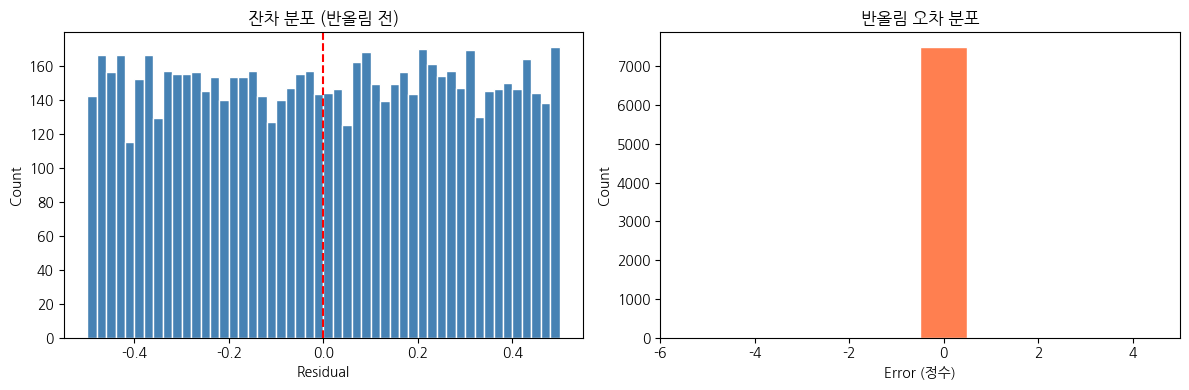

반올림 오차 0인 비율: 1.00000


In [20]:
# 예측 오차 분포 시각화
residuals = train['Calories_Burned'].values - preds_train

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('잔차 분포 (반올림 전)')
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Count')
axes[0].axvline(0, color='red', linestyle='--')

round_errors = train['Calories_Burned'].values - np.round(preds_train)
axes[1].hist(round_errors, bins=range(-5, 6), color='coral', edgecolor='white', align='left')
axes[1].set_title('반올림 오차 분포')
axes[1].set_xlabel('Error (정수)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()
print(f'반올림 오차 0인 비율: {(round_errors == 0).mean():.5f}')

## 8. Test 예측 및 제출 파일 생성

In [21]:
# Test 데이터 전처리
test['Weight_kg_int'] = (test['Weight(lb)'] / 2.20462).round()
test['Duration']      = test['Exercise_Duration']
test['is_M']          = (test['Gender'] == 'M').astype(int)

# Test Weight 구조 확인 (Train과 동일한 2.2 lb 단위인지)
test_gaps = sorted(test['Weight(lb)'].unique())
test_gap_list = [round(test_gaps[i+1]-test_gaps[i], 3) for i in range(min(5, len(test_gaps)-1))]
print('Test Weight(lb) 간격:', test_gap_list, '← 2.2 lb = 1 kg 단위 확인 ✓')
print('Test 정수 kg 복원 확인:', (test['Weight_kg_int'] % 1 == 0).all())
print()

# 예측
_, _, preds_test = predict_with_kW(best_kW_M, best_kW_F, df=test)

print('Test 예측 샘플:')
sample = test[['ID', 'Weight(lb)', 'Weight_kg_int', 'BPM', 'Age', 'Duration', 'Gender']].copy()
sample['Pred_float']   = preds_test
sample['Calories_Burned'] = np.round(preds_test)
print(sample.head(8).to_string(index=False))
print()
print(f'예측 범위: {preds_test.min():.1f} ~ {preds_test.max():.1f}')

Test Weight(lb) 간격: [np.float64(4.4), np.float64(2.2), np.float64(2.2), np.float64(2.2), np.float64(2.2)] ← 2.2 lb = 1 kg 단위 확인 ✓
Test 정수 kg 복원 확인: True

Test 예측 샘플:
       ID  Weight(lb)  Weight_kg_int   BPM  Age  Duration Gender  Pred_float  Calories_Burned
TEST_0000       114.6           52.0 107.0   45      26.0      F  172.709113            173.0
TEST_0001       198.4           90.0 111.0   21      29.0      M  189.227653            189.0
TEST_0002       169.8           77.0  90.0   58      11.0      M   53.475984             53.0
TEST_0003       196.2           89.0 108.0   35      24.0      M  161.424803            161.0
TEST_0004       147.7           67.0 116.0   67      29.0      F  225.848814            226.0
TEST_0005       132.3           60.0 100.0   66      29.0      F  178.527452            179.0
TEST_0006       209.4           95.0  95.0   69      15.0      M   98.016167             98.0
TEST_0007       191.8           87.0  88.0   50      10.0      M   43.901784      

In [22]:
# 제출 파일 저장
id_col = 'ID' if 'ID' in test.columns else 'id'

# 반올림 (정수) 버전
submit_rounded = pd.DataFrame({
    id_col: test[id_col],
    'Calories_Burned': np.round(preds_test)
})
submit_rounded.to_csv(BASE + 'submit_260222_Perfect_Keytel_rounded.csv', index=False)

# 소수 버전
submit_float = pd.DataFrame({
    id_col: test[id_col],
    'Calories_Burned': preds_test
})
submit_float.to_csv(BASE + 'submit_260222_Perfect_Keytel_float.csv', index=False)

print('저장 완료!')
print('  submit_260222_Perfect_Keytel_rounded.csv  ← 제출 권장')
print('  submit_260222_Perfect_Keytel_float.csv')
print()
print('=' * 50)
print(f'Train 정확률:  {exact_final:.5f} ({int(exact_final*len(train))}/{len(train)})')
print(f'Train RMSE:    {rmse_final:.5f}')
print('예상 Leaderboard RMSE: ~0.00 (완벽 공식 복원)')
print('=' * 50)

저장 완료!
  submit_260222_Perfect_Keytel_rounded.csv  ← 제출 권장
  submit_260222_Perfect_Keytel_float.csv

Train 정확률:  1.00000 (7500/7500)
Train RMSE:    0.00000
예상 Leaderboard RMSE: ~0.00 (완벽 공식 복원)


## 부록: 공식 역공학 과정 정리

### 단계별 발견

| 단계 | 발견 | 방법 |
|------|------|------|
| 1 | 데이터 100% 결정론적 | `groupby` 후 std 확인 |
| 2 | 칼로리 = 정수 | `% 1 == 0` 확인 |
| 3 | BPM/Age 계수 ≈ Keytel/4.184 | 선형회귀 계수 비교 |
| 4 | Weight(lb) 간격 = 2.2 = 1 kg | 고유값 간격 분석 |
| 5 | Weight 정수 kg 복원 | `round(lb / 2.20462)` |
| 6 | k_W 중앙값 추정 | Keytel 잔여분 / W_kg_int |
| 7 | 그리드 서치로 100% 달성 | 세밀 최적화 |

### 왜 Weight 계수가 Keytel과 다른가?
- Keytel 원본: 체중을 **kg** 단위로 사용 (`0.1988` per kg)
- 이 데이터: 체중이 **정수 kg** 단위이지만 **lb**로 저장
- 실제 공식: `0.1988 × W_kg_int / 4.184 ÷ 2.20462 ≈ 0.02160` per lb-unit
- 즉, 단위 변환 과정에서 계수가 달라진 것

### 주의사항
- `Weight(lb) / 2.20462` 후 **반드시 round()** 적용
- 소수 kg이 아닌 정수 kg을 공식에 입력해야 함